### Setup and Imports

In [131]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from scipy import interpolate as scipy_interpolate

### Data Ingestion

In [101]:
# Rounding the dates to month end, the last 4 Teasury notes are off

df = pd.read_excel("../Data/treasury_quotes_2025-11-28.xlsx", sheet_name="selected quotes")
df['quote date'] = df['quote date'] + pd.offsets.MonthEnd(0)
df['maturity date'] = df['maturity date'] + pd.offsets.MonthEnd(0)

## 1 Discounts Rates

In [102]:
max_date = df['maturity date'].max()
date_index = pd.date_range(start = "2026-05-31", end=max_date, freq=pd.offsets.MonthEnd(6)).round(freq='D')
date_index
cashflow = pd.DataFrame(columns = date_index, index = df['KYTREASNO'])
cashflow

,2026-05-31,2026-11-30,2027-05-31,2027-11-30,2028-05-31,2028-11-30,2029-05-31,2029-11-30,2030-05-31,2030-11-30,2031-05-31,2031-11-30,2032-05-31,2032-11-30,2033-05-31,2033-11-30,2034-05-31,2034-11-30,2035-05-31,2035-11-30
KYTREASNO,,,,,,,,,,,,,,,,,,,,
208227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208316,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208058,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [103]:

for index, note in df.iterrows():
    maturity = note['maturity date']
    coupon = note['cpn rate'] / 100
    par = 100
    freq = 2
    issue_date = ['issue date']
    payment_dates = pd.date_range(start='2025-11-30', end=maturity, freq=pd.offsets.MonthEnd(6)).round(freq='D')
    
    for pay_date in payment_dates:
        if pay_date in cashflow.columns:
            if pay_date == maturity:
                cashflow.at[note['KYTREASNO'], pay_date] = par * (1 + (coupon / freq))
            else:
                cashflow.at[note['KYTREASNO'], pay_date] = par * (coupon / freq)

cashflow.fillna(0, inplace=True)
cashflow

/var/folders/bg/6x82p8q55dxf8pb_c34j03mm0000gn/T/ipykernel_30908/3518927822.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cashflow.fillna(0, inplace=True)


,2026-05-31,2026-11-30,2027-05-31,2027-11-30,2028-05-31,2028-11-30,2029-05-31,2029-11-30,2030-05-31,2030-11-30,2031-05-31,2031-11-30,2032-05-31,2032-11-30,2033-05-31,2033-11-30,2034-05-31,2034-11-30,2035-05-31,2035-11-30
KYTREASNO,,,,,,,,,,,,,,,,,,,,
208227,102.4375,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208316,2.1250,102.1250,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208399,1.9375,1.9375,101.9375,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208484,1.6875,1.6875,1.6875,101.6875,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208058,1.8125,1.8125,1.8125,1.8125,101.8125,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208145,2.1875,2.1875,2.1875,2.1875,2.1875,102.1875,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208229,2.2500,2.2500,2.2500,2.2500,2.2500,2.2500,102.2500,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208318,2.0625,2.0625,2.0625,2.0625,2.0625,2.0625,2.0625,102.0625,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208401,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,102.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0


### 1.2 Optimization

Solve z in the equation $p = Cz$ 

In [104]:
print("Size of cashflow matrix:", cashflow.shape)

Size of cashflow matrix: (20, 20)


In [105]:
from scipy import linalg

C = np.array(cashflow)
p = np.array(df[['dirty price']])

z = linalg.solve(C, p)
z


array([[1.00487784],
       [0.98456231],
       [0.96652042],
       [0.93206534],
       [0.93375479],
       [0.92057273],
       [0.90459235],
       [0.88608551],
       [0.86931267],
       [0.833874  ],
       [0.83764848],
       [0.81847933],
       [0.80090596],
       [0.76431132],
       [0.74878459],
       [0.73235078],
       [0.71557912],
       [0.6984832 ],
       [0.6819603 ],
       [0.66624526]])

### 1.3 Plotting the discount rates and factors

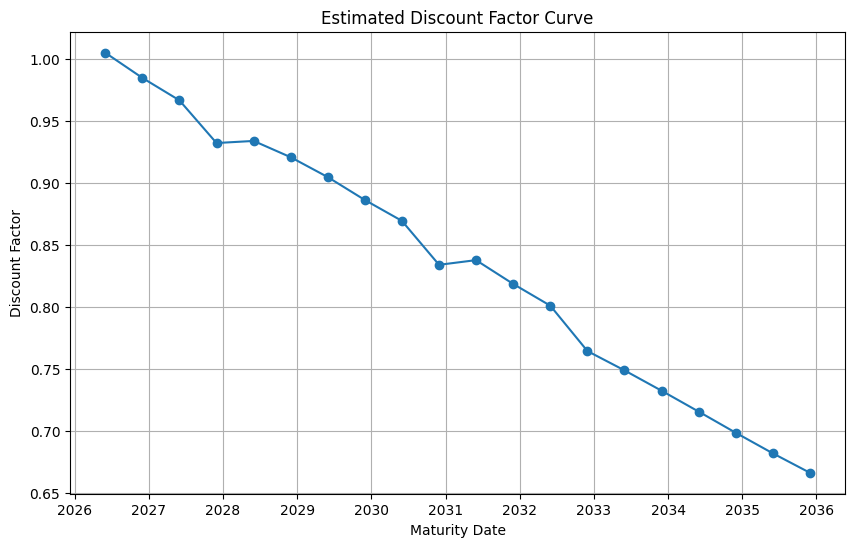

In [106]:
discount_factors = pd.DataFrame(data=z, index=date_index, columns=['Discount Factor'])
figure = plt.figure(figsize=(10,6))
plt.plot(discount_factors.index, discount_factors['Discount Factor'], marker='o')
plt.title('Estimated Discount Factor Curve')
plt.xlabel('Maturity Date')
plt.ylabel('Discount Factor')
plt.grid()
plt.show()

In [107]:
discount_factors

,Discount Factor
2026-05-31,1.004878
2026-11-30,0.984562
2027-05-31,0.966520
2027-11-30,0.932065
2028-05-31,0.933755
2028-11-30,0.920573
2029-05-31,0.904592
2029-11-30,0.886086
2030-05-31,0.869313
2030-11-30,0.833874


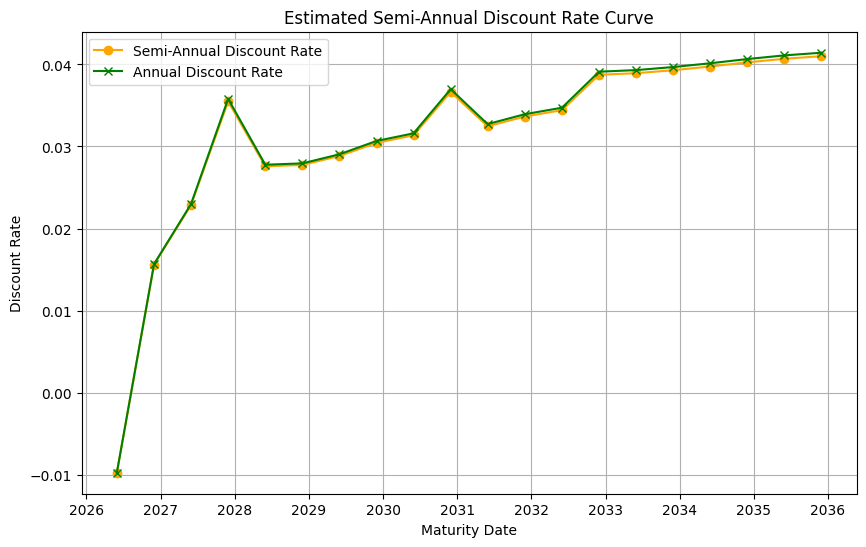

In [108]:

# Time to maturity in years
time_to_maturity = (date_index - pd.Timestamp("2025-11-30")).days / 365

# Annual compounding
annual_discount_rates = (1 / discount_factors['Discount Factor']) ** (1 / time_to_maturity) - 1

# Semi-annual compounding
semi_annual_discount_rates = 2 * ((1 / discount_factors['Discount Factor']) ** (1 / (2 * time_to_maturity)) - 1)

plt.figure(figsize=(10,6))
plt.plot(semi_annual_discount_rates.index, semi_annual_discount_rates, marker='o', color='orange')
plt.plot(annual_discount_rates.index, annual_discount_rates, marker='x', color='green')
plt.title('Estimated Semi-Annual Discount Rate Curve')
plt.xlabel('Maturity Date')
plt.ylabel('Discount Rate')
plt.legend(['Semi-Annual Discount Rate', 'Annual Discount Rate'])
plt.grid()
plt.show()

### 1.4 Curve Fitting With Nelson-Siegel


Payment dates: DatetimeIndex(['2026-05-31', '2026-11-30', '2027-05-31', '2027-11-30',
               '2028-05-31', '2028-11-30', '2029-05-31', '2029-11-30',
               '2030-05-31', '2030-11-30', '2031-05-31', '2031-11-30',
               '2032-05-31', '2032-11-30', '2033-05-31', '2033-11-30',
               '2034-05-31', '2034-11-30', '2035-05-31', '2035-11-30'],
              dtype='datetime64[ns]', freq=None)
Times (years): [0.5037645448323066, 1.0047912388774811, 1.5030800821355237, 2.004106776180698, 2.5051334702258727, 3.0061601642710474, 3.5044490075290895, 4.005475701574264, 4.503764544832307, 5.004791238877481, 5.503080082135524, 6.0041067761806985, 6.505133470225872, 7.006160164271047, 7.5044490075290895, 8.005475701574264, 8.503764544832306, 9.00479123887748, 9.503080082135524, 10.004106776180699]

Initial objective value: 108.29382470137126

First 5 bonds comparison:
Bond 0: Market=102.9372, Initial Model=100.7879
Bond 1: Market=102.6838, Initial Model=100.7909
Bond 2: 

/var/folders/bg/6x82p8q55dxf8pb_c34j03mm0000gn/T/ipykernel_30908/3660477766.py:61: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(objective, params, method='L-BFGS-B', bounds=bounds,


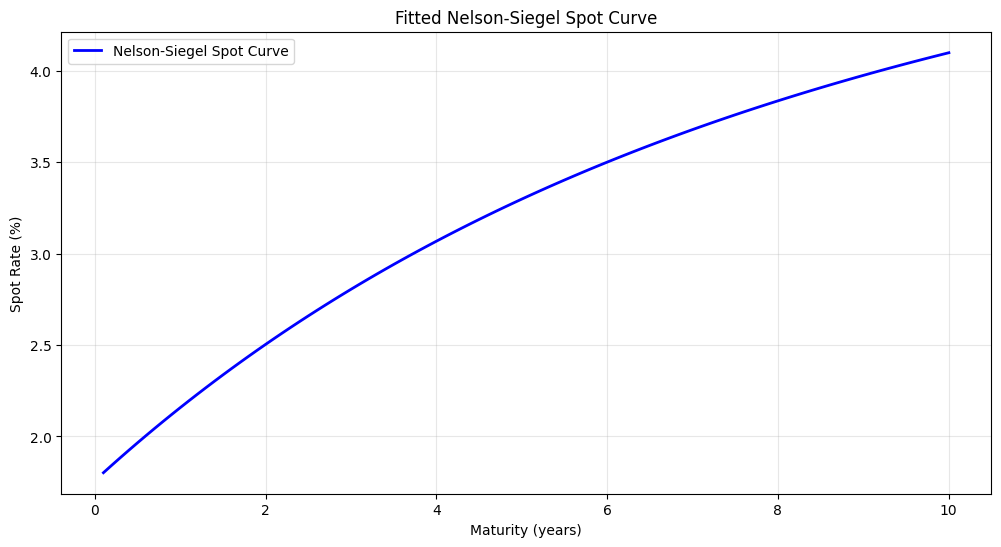


Optimal parameters dictionary: {'theta0': np.float64(0.0572454888244604), 'theta1': np.float64(-0.03965829182960861), 'theta2': np.float64(-5.7209870210964954e-05), 'lambda': np.float64(4.628482183425453)}


In [109]:
from scipy.optimize import minimize

# Your existing cashflow matrix
cashflow.fillna(0, inplace=True)

# Convert payment dates to time in years from today
today = pd.Timestamp('2025-11-28')  # or pd.Timestamp.today()
payment_dates = cashflow.columns
times_in_years = [(pd.Timestamp(date) - today).days / 365.25 for date in payment_dates]

print("Payment dates:", payment_dates)
print("Times (years):", times_in_years)

# Convert to numpy arrays for optimization
C = cashflow.values  # shape: (n_bonds, n_payment_dates)
market_prices = df['dirty price'].values
times = np.tile(times_in_years, (len(C), 1))  # same times for all bonds

# Nelson-Siegel spot rate formula
def ns_spot_rate(tau, theta0, theta1, theta2, lam):
    if tau <= 0:
        return theta0
    factor1 = (1 - np.exp(-tau/lam)) / (tau/lam)
    factor2 = factor1 - np.exp(-tau/lam)
    return theta0 + theta1 * factor1 + theta2 * factor2

# Calculate model prices for given parameters
def calculate_model_prices(params):
    theta0, theta1, theta2, lam = params
    model_prices = []
    
    for i in range(len(C)):
        price = 0
        for j in range(len(times_in_years)):
            if C[i, j] != 0 and times_in_years[j] > 0:
                spot = ns_spot_rate(times_in_years[j], theta0, theta1, theta2, lam)
                df = np.exp(-spot * times_in_years[j])
                price += C[i, j] * df
        model_prices.append(price)
    
    return np.array(model_prices)

# Objective: minimize squared pricing errors
def objective(params):
    model_prices = calculate_model_prices(params)
    errors = market_prices - model_prices
    return np.sum(errors**2)

# Initial parameter guess: [theta0, theta1, theta2, lambda]
params = np.array([0.04, -0.01, 0.01, 2.0])

# Test with initial parameters
print("\nInitial objective value:", objective(params))
initial_prices = calculate_model_prices(params)
print("\nFirst 5 bonds comparison:")
for i in range(min(5, len(market_prices))):
    print(f"Bond {i}: Market={market_prices[i]:.4f}, Initial Model={initial_prices[i]:.4f}")

# Optimize
bounds = [(0.0, 0.15), (-0.1, 0.1), (-0.1, 0.1), (0.1, 10.0)]
result = minimize(objective, params, method='L-BFGS-B', bounds=bounds, 
                 options={'maxiter': 1000, 'disp': True})

print("\n" + "="*50)
print("Optimization result:")
print("="*50)
print(f"Success: {result.success}")
print(f"Optimal θ₀: {result.x[0]:.6f}")
print(f"Optimal θ₁: {result.x[1]:.6f}")
print(f"Optimal θ₂: {result.x[2]:.6f}")
print(f"Optimal λ: {result.x[3]:.6f}")
print(f"Final SSE: {result.fun:.6f}")

# Check final fit
optimal_prices = calculate_model_prices(result.x)
print("\nFinal price comparison:")
for i in range(len(market_prices)):
    error = market_prices[i] - optimal_prices[i]
    pct_error = (error / market_prices[i]) * 100
    print(f"Bond {df.iloc[i]['KYTREASNO']}: Market={market_prices[i]:.4f}, "
          f"Model={optimal_prices[i]:.4f}, Error={error:.4f} ({pct_error:.2f}%)")

# Calculate RMSE
rmse = np.sqrt(result.fun / len(market_prices))
print(f"\nRMSE: {rmse:.6f}")
print(f"Mean Absolute Error: {np.mean(np.abs(market_prices - optimal_prices)):.6f}")

# Extract and plot the optimal spot curve
optimal_params = result.x
maturities = np.linspace(0.1, max(times_in_years), 100)
spot_rates = [ns_spot_rate(t, *optimal_params) for t in maturities]

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(maturities, np.array(spot_rates) * 100, 'b-', linewidth=2, label='Nelson-Siegel Spot Curve')
plt.xlabel('Maturity (years)')
plt.ylabel('Spot Rate (%)')
plt.title('Fitted Nelson-Siegel Spot Curve')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Store the optimal parameters for later use
ns_params = {
    'theta0': result.x[0],
    'theta1': result.x[1],
    'theta2': result.x[2],
    'lambda': result.x[3]
}
print("\nOptimal parameters dictionary:", ns_params)

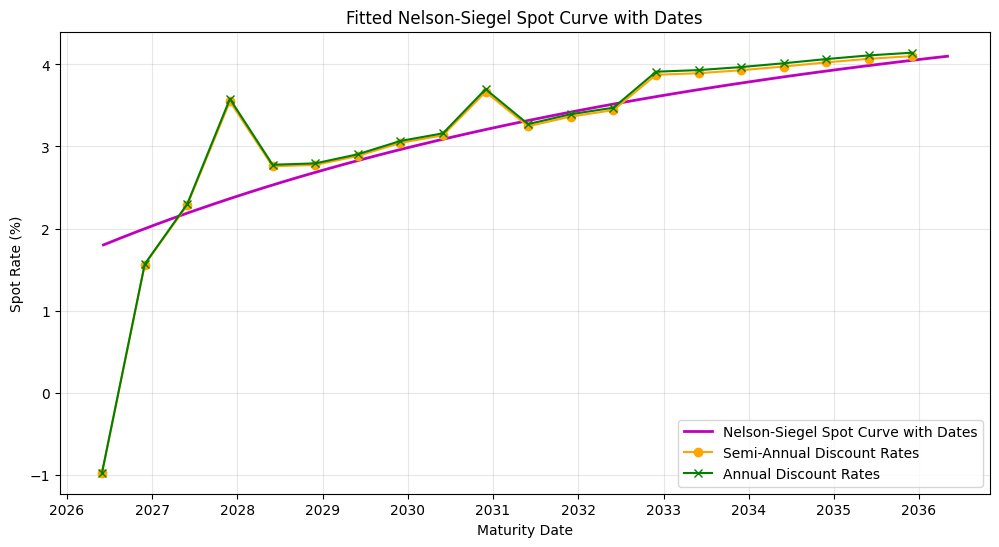

In [110]:
spot_rate_with_dates = pd.DataFrame({
    'Maturity Date': [pd.Timestamp("2026-05-01") + pd.DateOffset(days=int(m * 365.25)) for m in maturities],
    'Spot Rate (%)': np.array(spot_rates) * 100
})


plt.figure(figsize=(12, 6))
plt.plot(spot_rate_with_dates['Maturity Date'], spot_rate_with_dates['Spot Rate (%)'], 'm-', linewidth=2, label='Nelson-Siegel Spot Curve with Dates')
plt.plot(semi_annual_discount_rates.index, semi_annual_discount_rates * 100, marker='o', color='orange', label='Semi-Annual Discount Rates')
plt.plot(annual_discount_rates.index, annual_discount_rates * 100, marker='x', color='green', label='Annual Discount Rates')
plt.xlabel('Maturity Date')
plt.ylabel('Spot Rate (%)')
plt.title('Fitted Nelson-Siegel Spot Curve with Dates')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 2 Estimating the Discount Curve with Non Evenly Spaced Data

In [111]:
dt = pd.read_excel("../Data/treasury_quotes_2025-11-28.xlsx", sheet_name="quotes")
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   KYTREASNO         455 non-null    int64         
 1   type              455 non-null    object        
 2   quote date        455 non-null    datetime64[ns]
 3   issue date        455 non-null    datetime64[ns]
 4   maturity date     455 non-null    datetime64[ns]
 5   ttm               455 non-null    float64       
 6   accrual fraction  403 non-null    float64       
 7   cpn rate          455 non-null    float64       
 8   bid               455 non-null    float64       
 9   ask               455 non-null    float64       
 10  price             455 non-null    float64       
 11  accrued int       455 non-null    float64       
 12  dirty price       455 non-null    float64       
 13  ytm               402 non-null    float64       
 14  total size        449 non-

In [112]:
dt = dt[(dt['ytm'] >= 0) & (dt['type'].isin(['note', 'bond']))] 
dt

,KYTREASNO,type,quote date,issue date,maturity date,ttm,accrual fraction,cpn rate,bid,ask,price,accrued int,dirty price,ytm,total size,duration
4,207988,note,2025-11-28,2022-12-15,2025-12-15,0.046543,0.907104,4.000,99.998315,99.998711,99.998513,1.814208,101.812721,0.039877,3.999900e+10,0.046575
10,208158,note,2025-11-28,2023-12-31,2025-12-31,0.090349,0.820652,4.250,100.033357,100.034455,100.033906,1.743886,101.777792,0.038052,5.526400e+10,0.090411
11,207652,note,2025-11-28,2020-12-31,2025-12-31,0.090349,0.820652,0.375,99.719342,99.720419,99.719880,0.153872,99.873753,0.035019,6.787700e+10,0.090411
12,207297,note,2025-11-28,2018-12-31,2025-12-31,0.090349,0.820652,2.625,99.891064,99.892153,99.891608,1.077106,100.968714,0.037978,3.199600e+10,0.090411
18,208001,note,2025-11-28,2023-01-15,2026-01-15,0.131417,0.739130,3.875,99.994531,100.000706,99.997618,1.432065,101.429684,0.038365,3.999800e+10,0.131507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,208322,bond,2025-11-28,2024-11-15,2054-11-15,28.963723,0.071823,4.500,97.199219,97.257812,97.228516,0.161602,97.390118,0.046760,8.006300e+10,16.261140
451,208362,bond,2025-11-28,2025-02-15,2055-02-15,29.215606,0.570652,4.625,99.246094,99.300781,99.273437,1.319633,100.593071,0.046705,7.990100e+10,16.056723
452,208405,bond,2025-11-28,2025-05-15,2055-05-15,29.459274,0.071823,4.750,101.296875,101.359375,101.328125,0.170580,101.498705,0.046673,8.080300e+10,16.217796
453,208448,bond,2025-11-28,2025-08-15,2055-08-15,29.711157,0.570652,4.750,101.328125,101.390625,101.359375,1.355299,102.714674,0.046650,7.787900e+10,16.100166


### 2.1 Mapping Cashflows
### Below functions are imported from Mark's Repo

In [113]:
import datetime


def calc_cashflows(quote_data, filter_maturity_dates=False):
    
    CF = pd.DataFrame(dtype=float, data=0, index=quote_data.index, columns=quote_data['TMATDT'].unique())

    for i in quote_data.index:
        coupon_dates = get_coupon_dates(quote_data.loc[i,'CALDT'],quote_data.loc[i,'TMATDT'])

        if coupon_dates is not None:
            CF.loc[i,coupon_dates] = quote_data.loc[i,'TCOUPRT']/2

        CF.loc[i,quote_data.loc[i,'TMATDT']] += 100


    CF = CF.fillna(0).sort_index(axis=1)
    CF.drop(columns=CF.columns[(CF==0).all()],inplace=True)

    if filter_maturity_dates:
        CF = filter_treasury_cashflows(CF, filter_maturity_dates=True)
        
    return CF

def get_coupon_dates(quote_date,maturity_date):

    if isinstance(quote_date,str):
        quote_date = datetime.datetime.strptime(quote_date,'%Y-%m-%d')
        
    if isinstance(maturity_date,str):
        maturity_date = datetime.datetime.strptime(maturity_date,'%Y-%m-%d')
    
    # divide by 180 just to be safe
    temp = pd.date_range(end=maturity_date, periods=int(np.ceil((maturity_date-quote_date).days/180)), freq=pd.DateOffset(months=6))
    # filter out if one date too many
    temp = pd.DataFrame(data=temp[temp > quote_date])

    out = temp[0]
    return out


def filter_treasury_cashflows(CF, filter_maturity_dates=False, filter_benchmark_dates=False, filter_CF_strict=True):

    mask_benchmark_dts = []
    
    # Filter by using only benchmark treasury dates
    for col in CF.columns:
        if filter_benchmark_dates:
            if col.month in [2,5,8,11] and col.day == 15:
                mask_benchmark_dts.append(col)
        else:
            mask_benchmark_dts.append(col)
    
    if filter_maturity_dates:
        mask_maturity_dts = CF.columns[(CF>=100).any()]
    else:
        mask_maturity_dts = CF.columns
    
    mask = [i for i in mask_benchmark_dts if i in mask_maturity_dts]

    CF_filtered = CF[mask]
          
    if filter_CF_strict:
        # drop issues that had CF on excluded dates
        mask_bnds = CF_filtered.sum(axis=1) == CF.sum(axis=1)
        CF_filtered = CF_filtered[mask_bnds]

    else:
        # drop issues that have no CF on included dates
        mask_bnds = CF_filtered.sum(axis=1) > 0
        CF_filtered = CF_filtered[mask_bnds]
        
        
    # update to drop dates with no CF
    CF_filtered = CF_filtered.loc[:,(CF_filtered>0).any()]
    
    return CF_filtered


In [114]:
dt_renamed = dt.rename(columns={
    'maturity date': 'TMATDT',
    'cpn rate': 'TCOUPRT'
})

# CRITICAL: Use the pricing date, NOT issue date
dt_renamed['CALDT'] = pd.Timestamp('2025-11-28')  # The date you're pricing bonds

# Step 1: Calculate cashflows WITHOUT filtering
CF = calc_cashflows(dt_renamed, filter_maturity_dates=False)

print(f"Initial CF matrix: {CF.shape}")
print(f"Sample cashflows:")
print(CF.iloc[:5, -10:])  # Look at last 10 columns (near maturity)

# Step 2: Apply filters separately
CF_filtered = filter_treasury_cashflows(
    CF, 
    filter_benchmark_dates=True,      # Keep only Feb/May/Aug/Nov 15
    filter_maturity_dates=True
)

CF_filtered

Initial CF matrix: (350, 266)
Sample cashflows:
    2053-08-15  2053-11-15  2054-02-15  2054-05-15  2054-08-15  2054-11-15  \
4          0.0         0.0         0.0         0.0         0.0         0.0   
10         0.0         0.0         0.0         0.0         0.0         0.0   
11         0.0         0.0         0.0         0.0         0.0         0.0   
12         0.0         0.0         0.0         0.0         0.0         0.0   
18         0.0         0.0         0.0         0.0         0.0         0.0   

    2055-02-15  2055-05-15  2055-08-15  2055-11-15  
4          0.0         0.0         0.0         0.0  
10         0.0         0.0         0.0         0.0  
11         0.0         0.0         0.0         0.0  
12         0.0         0.0         0.0         0.0  
18         0.0         0.0         0.0         0.0  


,2026-02-15,2026-05-15,2026-08-15,2026-11-15,2027-02-15,2027-05-15,2027-08-15,2027-11-15,2028-02-15,2028-05-15,...,2033-11-15,2034-02-15,2034-05-15,2034-08-15,2034-11-15,2035-02-15,2035-05-15,2035-08-15,2035-11-15,2036-02-15
32,102.0000,0.0000,0.0000,0.000,0.0000,0.000,0.0000,0.000,0.0000,0.000,...,0.000,0.0000,0.000,0.0000,0.000,0.0000,0.000,0.000,0.0,0.00
33,100.8125,0.0000,0.0000,0.000,0.0000,0.000,0.0000,0.000,0.0000,0.000,...,0.000,0.0000,0.000,0.0000,0.000,0.0000,0.000,0.000,0.0,0.00
34,103.0000,0.0000,0.0000,0.000,0.0000,0.000,0.0000,0.000,0.0000,0.000,...,0.000,0.0000,0.000,0.0000,0.000,0.0000,0.000,0.000,0.0,0.00
67,0.0000,100.8125,0.0000,0.000,0.0000,0.000,0.0000,0.000,0.0000,0.000,...,0.000,0.0000,0.000,0.0000,0.000,0.0000,0.000,0.000,0.0,0.00
68,0.0000,101.8125,0.0000,0.000,0.0000,0.000,0.0000,0.000,0.0000,0.000,...,0.000,0.0000,0.000,0.0000,0.000,0.0000,0.000,0.000,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338,2.3125,0.0000,2.3125,0.000,2.3125,0.000,2.3125,0.000,2.3125,0.000,...,0.000,2.3125,0.000,2.3125,0.000,102.3125,0.000,0.000,0.0,0.00
339,0.0000,2.1250,0.0000,2.125,0.0000,2.125,0.0000,2.125,0.0000,2.125,...,2.125,0.0000,2.125,0.0000,2.125,0.0000,102.125,0.000,0.0,0.00
341,2.1250,0.0000,2.1250,0.000,2.1250,0.000,2.1250,0.000,2.1250,0.000,...,0.000,2.1250,0.000,2.1250,0.000,2.1250,0.000,102.125,0.0,0.00
342,0.0000,2.0000,0.0000,2.000,0.0000,2.000,0.0000,2.000,0.0000,2.000,...,2.000,0.0000,2.000,0.0000,2.000,0.0000,2.000,0.000,102.0,0.00


In [115]:
display(CF_filtered.head(1))
display(CF_filtered.tail(1))

,2026-02-15,2026-05-15,2026-08-15,2026-11-15,2027-02-15,2027-05-15,2027-08-15,2027-11-15,2028-02-15,2028-05-15,...,2033-11-15,2034-02-15,2034-05-15,2034-08-15,2034-11-15,2035-02-15,2035-05-15,2035-08-15,2035-11-15,2036-02-15
32,102.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,2026-02-15,2026-05-15,2026-08-15,2026-11-15,2027-02-15,2027-05-15,2027-08-15,2027-11-15,2028-02-15,2028-05-15,...,2033-11-15,2034-02-15,2034-05-15,2034-08-15,2034-11-15,2035-02-15,2035-05-15,2035-08-15,2035-11-15,2036-02-15
343,2.25,0.0,2.25,0.0,2.25,0.0,2.25,0.0,2.25,0.0,...,0.0,2.25,0.0,2.25,0.0,2.25,0.0,2.25,0.0,102.25


In [116]:
#Most Cashflow:
total_cashflow_by_date = CF_filtered.sum(axis=0)
max_cf_date = total_cashflow_by_date.idxmax()
max_cf_value = total_cashflow_by_date.max()

print("Date with most total cashflow:", max_cf_date)
print("Total cashflow on that date:", max_cf_value)


#Most Issues Paying:
issues_paying_by_date = (CF_filtered > 0).sum(axis=0)
max_issues_date = issues_paying_by_date.idxmax()
max_issues_count = issues_paying_by_date.max()

print("Date with most issues paying:", max_issues_date)
print("Number of issues paying:", max_issues_count)

Date with most total cashflow: 2026-02-15 00:00:00
Total cashflow on that date: 363.6875
Date with most issues paying: 2026-02-15 00:00:00
Number of issues paying: 35


### 2.2 OLS
### OLS function imported from Mark's repo

In [117]:
from sklearn.linear_model import LinearRegression

def estimate_curve_ols(CF,prices,interpolate=False):

    if isinstance(prices,pd.DataFrame) or isinstance(prices,pd.Series):
        prices = prices[CF.index].values
    
    mod = LinearRegression(fit_intercept=False).fit(CF.values,prices)

    if interpolate:
        matgrid = get_maturity_delta(CF.columns,CF.columns.min())

        dts_valid = np.logical_and(mod.coef_<1.25, mod.coef_>0)

        xold = matgrid[dts_valid]
        xnew = matgrid
        yold = mod.coef_[dts_valid]

        f = interpolate.interp1d(xold, yold, bounds_error=False, fill_value='extrapolate')    
        discounts = f(xnew)

    else:
        discounts = mod.coef_    
        
    return discounts

def get_maturity_delta(t_maturity,t_current):

    maturity_delta = (t_maturity - t_current) / pd.Timedelta('365.25 days')
    
    return maturity_delta


discounts = estimate_curve_ols(CF_filtered, dt.loc[CF_filtered.index, 'dirty price'],interpolate=False)


In [118]:
print(len(CF.columns))
print(len(discounts))

266
41


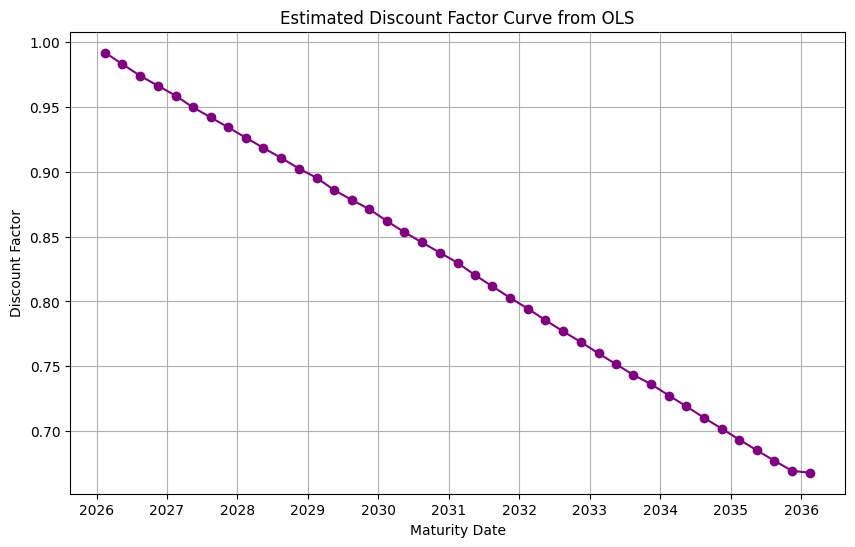

In [119]:
plt.figure(figsize=(10,6))
plt.plot(CF_filtered.columns, discounts, marker='o', color='purple')
plt.title('Estimated Discount Factor Curve from OLS')
plt.xlabel('Maturity Date')
plt.ylabel('Discount Factor')
plt.grid()
plt.show()

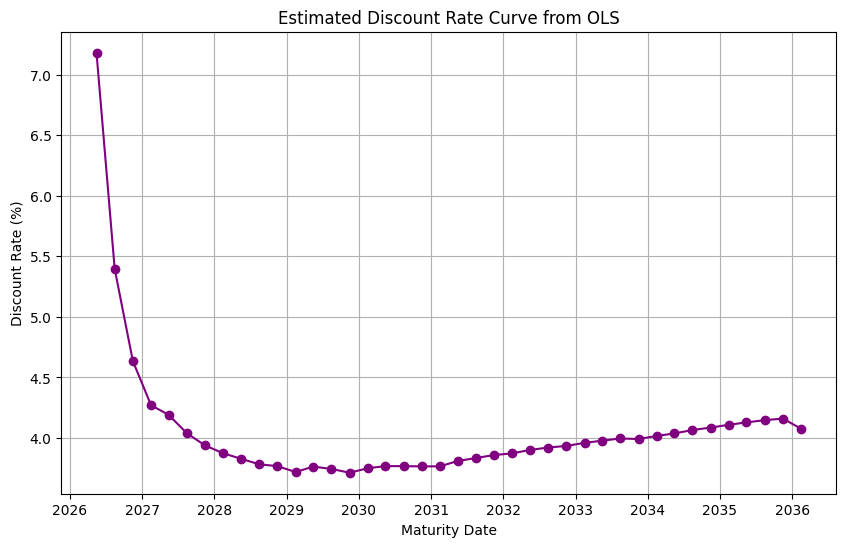

In [120]:
discount_rate =  2 * ((1 / discounts) ** (1 / (2 * get_maturity_delta(CF_filtered.columns,CF_filtered.columns.min()))) - 1)

plt.figure(figsize=(10,6))
plt.plot(CF_filtered.columns, discount_rate * 100, marker='o', color='purple')
plt.title('Estimated Discount Rate Curve from OLS')
plt.xlabel('Maturity Date')
plt.ylabel('Discount Rate (%)')
plt.grid()
plt.show()

### 2.3 Nelson Siegel - Borrowing Mark's Code

In [121]:
def estimate_rate_curve(model,CF,t_current,prices,x0=None):

    if model is bootstrap:
        params = estimate_curve_ols(CF,prices,interpolate=False)
        
        CF_intervals = get_maturity_delta(CF.columns.to_series(),t_current=t_current).values
    
        params_optimized = [CF_intervals,params]

    else:
        if x0 is None:
            if model is nelson_siegel:
                x0 = np.ones(4)/10
            elif model is nelson_siegel_extended:
                x0 = np.ones(6)
            else:
                x0 = 1        

        mod = minimize(pricing_errors, x0, args=(CF, t_current, model, prices))
        params_optimized = mod.x

    return params_optimized

def nelson_siegel(params,maturity):
    rate = params[0] + (params[1] + params[2]) * (1 - np.exp(-maturity/params[3]))/(maturity/params[3]) - params[2] * np.exp(-maturity/params[3])
    
    return rate


def nelson_siegel_extended(params,maturity):
    rate = params[0] + (params[1] + params[2]) * (1 - np.exp(-maturity/params[3]))/(maturity/params[3]) - params[2] * np.exp(-maturity/params[3]) + params[4] *((1-np.exp(-maturity/params[5]))/(maturity/params[5]) - np.exp(-maturity/params[5]))
    
    return rate


def pricing_errors(params,CF,t_current,fun_model,observed_prices):

    price_modeled = price_with_rate_model(params,CF,t_current,fun_model)

    if isinstance(observed_prices,pd.DataFrame) or isinstance(observed_prices,pd.Series):
        observed_prices = observed_prices.values
        
    error = sum((observed_prices - price_modeled)**2)
    
    return error

def price_with_rate_model(params,CF,t_current,fun_model, convert_to_discount=True, price_coupons=False):

    maturity = get_maturity_delta(CF.columns, t_current)
    
    if convert_to_discount:
        disc = np.zeros(maturity.shape)
        for i, mat in enumerate(maturity):
            disc[i] = intrate_to_discount(fun_model(params,mat),mat)
    else:
        disc = fun(params,mat)
        
        
    if price_coupons:
        price = CF * disc
    else:
        price = CF @ disc
    
    return price

def intrate_to_discount(intrate, maturity, n_compound=None):
    
    if n_compound is None:
        discount = np.exp(-intrate * maturity)
    else:
        discount = 1 / (1+(intrate / n_compound))**(n_compound * maturity)

    return discount    


def bootstrap(params,maturity):
    estimated_maturities = params[0]
    betas = params[1]
    estimated_rates = discount_to_intrate(betas,estimated_maturities)
    
    f = interpolate.interp1d(estimated_maturities, estimated_rates, bounds_error=False, fill_value='extrapolate')
    
    rate = f(maturity)

    return rate

/var/folders/bg/6x82p8q55dxf8pb_c34j03mm0000gn/T/ipykernel_30908/4092109883.py:69: RuntimeWarning: overflow encountered in exp
  discount = np.exp(-intrate * maturity)
/opt/anaconda3/envs/finm/lib/python3.12/site-packages/pandas/core/frame.py:1767: RuntimeWarning: invalid value encountered in dot
  result = np.dot(lvals, rvals)
/var/folders/bg/6x82p8q55dxf8pb_c34j03mm0000gn/T/ipykernel_30908/4092109883.py:69: RuntimeWarning: overflow encountered in exp
  discount = np.exp(-intrate * maturity)
/opt/anaconda3/envs/finm/lib/python3.12/site-packages/pandas/core/frame.py:1767: RuntimeWarning: invalid value encountered in dot
  result = np.dot(lvals, rvals)


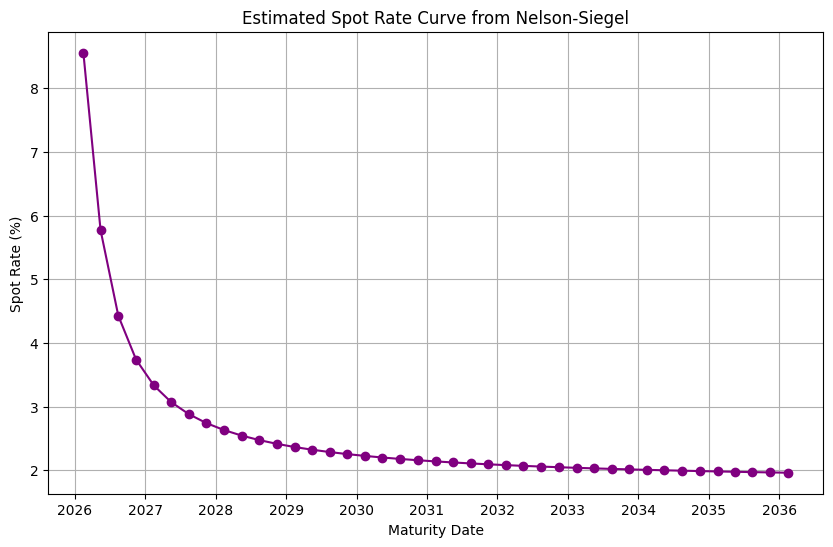

In [122]:
spot_rate_Nelson_Siegel = estimate_rate_curve(nelson_siegel,CF_filtered,t_current=dt_renamed['CALDT'].min(),prices=dt.loc[CF_filtered.index,'dirty price'])
plt.figure(figsize=(10,6))
plt.plot(CF_filtered.columns, nelson_siegel(spot_rate_Nelson_Siegel, get_maturity_delta(CF_filtered.columns, dt_renamed['CALDT'].min())) * 100, marker='o', color='purple')
plt.title('Estimated Spot Rate Curve from Nelson-Siegel')
plt.xlabel('Maturity Date')
plt.ylabel('Spot Rate (%)')
plt.grid()
plt.show()

### 2.4 Weighted OLS

In [134]:
from scipy import interpolate as scipy_interpolate

def estimate_curve_wls(CF, prices, issue_dates, quote_date, interpolate=False, weight_halflife=2.0):
    """
    Estimate discount curve using Weighted Least Squares (WLS)
    
    Parameters:
    -----------
    CF : DataFrame
        Cash flow matrix (bonds × payment dates)
    prices : array-like or Series
        Market prices
    issue_dates : array-like or Series
        Issue dates for each bond
    quote_date : datetime
        Current pricing date
    interpolate : bool
        Whether to interpolate invalid discount factors
    weight_halflife : float
        Half-life in years for exponential weighting (default 2.0)
        Lower values put more weight on recent issues
    
    Returns:
    --------
    array: Discount factors for each payment date
    """
    
    if isinstance(prices, pd.DataFrame) or isinstance(prices, pd.Series):
        prices = prices[CF.index].values
    
    if isinstance(issue_dates, pd.Series):
        issue_dates = issue_dates[CF.index].values
    
    # Calculate time since issue in years
    time_since_issue = np.array([(quote_date - pd.Timestamp(date)).days / 365.25 
                                  for date in issue_dates])
    
    # Calculate weights using exponential decay
    decay_rate = np.log(2) / weight_halflife
    weights = np.exp(-decay_rate * time_since_issue)
    
    # Normalize weights
    weights = weights / weights.sum() * len(weights)
    
    # Create weighted design matrix
    W = np.diag(np.sqrt(weights))
    X_weighted = W @ CF.values
    y_weighted = W @ prices
    
    # Fit weighted least squares
    mod = LinearRegression(fit_intercept=False).fit(X_weighted, y_weighted)
    
    if interpolate:
        matgrid = get_maturity_delta(CF.columns, CF.columns.min())
        dts_valid = np.logical_and(mod.coef_ < 1.25, mod.coef_ > 0)
        
        if dts_valid.sum() < 2:
            print("Warning: Less than 2 valid discount factors. Returning raw coefficients.")
            return mod.coef_
        
        xold = matgrid[dts_valid]
        xnew = matgrid
        yold = mod.coef_[dts_valid]
        
        # Use scipy_interpolate instead of just interpolate
        f = scipy_interpolate.interp1d(xold, yold, bounds_error=False, fill_value='extrapolate')
        discounts = f(xnew)
    else:
        discounts = mod.coef_
    
    return discounts

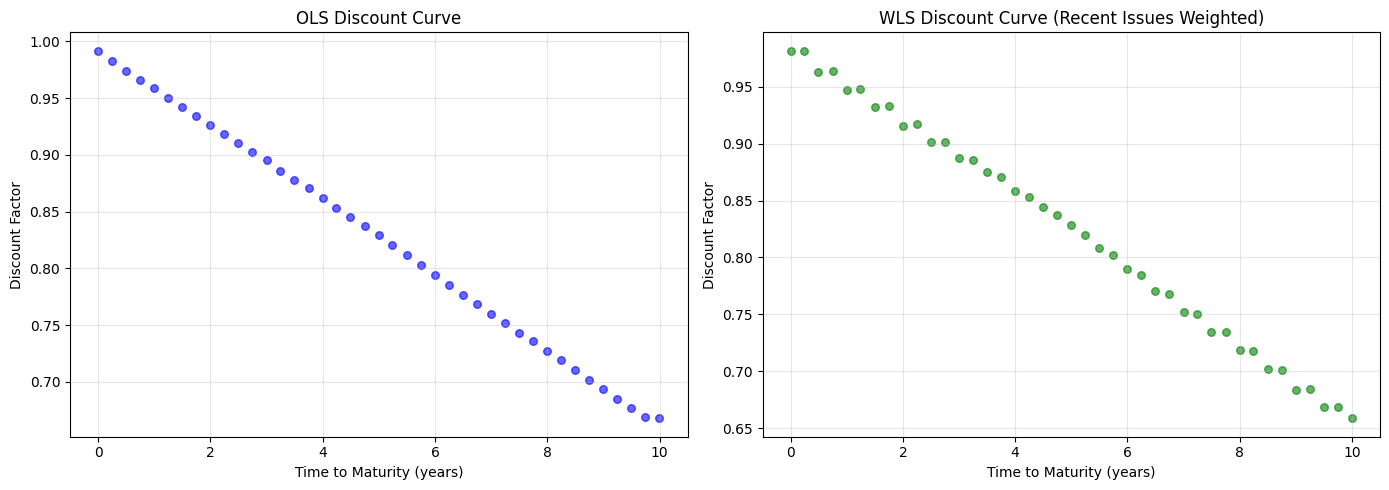

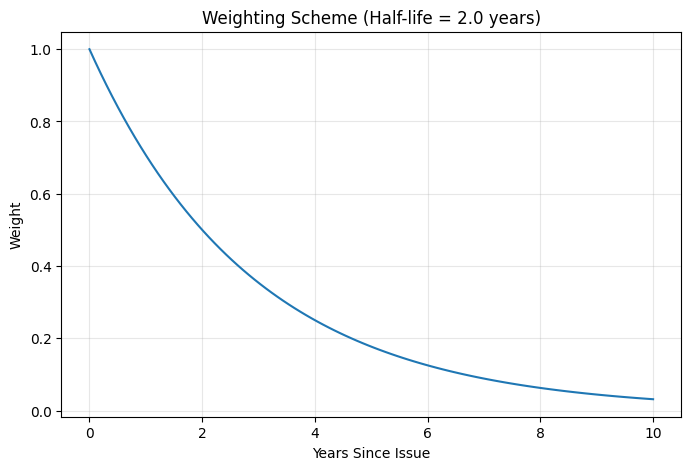

In [137]:
# Calculate WLS discount factors
discounts_wls = estimate_curve_wls(
    CF_filtered,
    dt_renamed.loc[CF_filtered.index, 'price'],
    dt_renamed.loc[CF_filtered.index, 'issue date'],
    quote_date=pd.Timestamp('2025-11-28'),
    interpolate=True,
    weight_halflife=2.0  # Adjust this: lower = more weight on recent issues
)

# Compare OLS vs WLS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OLS
maturities = get_maturity_delta(CF_filtered.columns, CF_filtered.columns.min())
valid_ols = (discounts > 0.01) & (discounts <= 1.0)
axes[0].scatter(maturities[valid_ols], discounts[valid_ols], alpha=0.6, s=30, color='blue')
axes[0].set_xlabel('Time to Maturity (years)')
axes[0].set_ylabel('Discount Factor')
axes[0].set_title('OLS Discount Curve')
axes[0].grid(True, alpha=0.3)

# WLS
valid_wls = (discounts_wls > 0.01) & (discounts_wls <= 1.0)
axes[1].scatter(maturities[valid_wls], discounts_wls[valid_wls], alpha=0.6, s=30, color='green')
axes[1].set_xlabel('Time to Maturity (years)')
axes[1].set_ylabel('Discount Factor')
axes[1].set_title('WLS Discount Curve (Recent Issues Weighted)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Convert to semi-annual rates
semi_annual_wls = 2 * ((1 / discounts_wls[valid_wls]) ** (1 / (2 * maturities[valid_wls])) - 1) * 100

# Show weight distribution
weights_example = np.exp(-np.log(2)/2.0 * np.linspace(0, 10, 100))
plt.figure(figsize=(8, 5))
plt.plot(np.linspace(0, 10, 100), weights_example)
plt.xlabel('Years Since Issue')
plt.ylabel('Weight')
plt.title(f'Weighting Scheme (Half-life = 2.0 years)')
plt.grid(True, alpha=0.3)
plt.show()